# Loan Repayment Prediction using Logistic Regression

## Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


## Load Dataset

In [2]:
data = pd.read_csv(r"Loan_Repayment_Training_Data.csv")

data.head(10)

,Age,Annual Income (LPA),Borrowed Amount (LPA),Credit Score,Loan Tenure (months),Employment Status,Existing Loans,Marital Status,Education Level,Repayment
0,25,13.40,1.00,501,236,Self-Employed,3,Single,Graduate,0
1,56,5.57,12.30,545,115,Salaried,3,Single,Graduate,0
2,50,8.73,22.09,803,72,Self-Employed,1,Single,Post-Graduate,1
3,41,18.80,1.00,761,129,Self-Employed,2,Married,Graduate,1
4,41,8.86,16.05,615,192,Salaried,4,Married,Graduate,0
5,59,15.43,7.70,545,83,Self-Employed,2,Single,High School,0
6,25,5.40,9.57,450,22,Self-Employed,0,Single,High School,0
7,52,9.77,2.63,631,23,Self-Employed,3,Married,High School,0
8,30,5.30,7.66,870,206,Self-Employed,2,Married,Graduate,1
9,26,8.97,19.10,719,37,Unemployed,2,Married,Graduate,0


## Define X and y

In [3]:
X = data.drop("Repayment ", axis=1)
y = data["Repayment "]


In [4]:
categorical_cols = ["Employment Status","Marital Status","Education Level"]

X = pd.get_dummies(X,columns=categorical_cols)

X.head()

,Age,Annual Income (LPA),Borrowed Amount (LPA),Credit Score,Loan Tenure (months),Existing Loans,Employment Status_Salaried,Employment Status_Self-Employed,Employment Status_Unemployed,Marital Status_Married,Marital Status_Single,Education Level_Graduate,Education Level_High School,Education Level_Post-Graduate
0,25,13.40,1.00,501,236,3,False,True,False,False,True,True,False,False
1,56,5.57,12.30,545,115,3,True,False,False,False,True,True,False,False
2,50,8.73,22.09,803,72,1,False,True,False,False,True,False,False,True
3,41,18.80,1.00,761,129,2,False,True,False,True,False,True,False,False
4,41,8.86,16.05,615,192,4,True,False,False,True,False,True,False,False


In [5]:
print(data.isnull().sum())

Age                      0
Annual Income (LPA)      0
Borrowed Amount (LPA)    0
Credit Score             0
Loan Tenure (months)     0
Employment Status        0
Existing Loans           0
Marital Status           0
Education Level          0
Repayment                0
dtype: int64


## Split the data into training and testing sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Train the logistic regression model

In [7]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
model.fit(X_train, y_train)

print("Model trained Successfully")


Model trained Successfully


c:\Users\Bhupe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Make predictions on the test set

In [8]:
y_pred = model.predict(X_test)

# Evaluate the model

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy*100, "%")


Accuracy: 65.0 %


## Classification Report

In [9]:
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[10  7]
 [ 7 16]]
              precision    recall  f1-score   support

           0       0.59      0.59      0.59        17
           1       0.70      0.70      0.70        23

    accuracy                           0.65        40
   macro avg       0.64      0.64      0.64        40
weighted avg       0.65      0.65      0.65        40



## Load Dataset

In [10]:
new_data = pd.read_csv(r"Loan_Repayment_Test_Data_NoLabel.csv")

new_data.head()

,Age,Annual Income (LPA),Borrowed Amount (LPA),Credit Score,Loan Tenure (months),Employment Status,Existing Loans,Marital Status,Education Level
0,35,5.56,7.84,647,221,Salaried,2,Married,Graduate
1,47,16.97,14.23,856,39,Self-Employed,2,Single,Graduate
2,25,8.77,5.36,596,30,Salaried,1,Married,Post-Graduate
3,22,9.64,10.40,618,128,Salaried,2,Single,Post-Graduate
4,58,13.50,14.40,765,239,Salaried,0,Married,Graduate


In [11]:
text_cols = ["Employment Status","Marital Status","Education Level"]

X_dummies = pd.get_dummies(new_data,columns=text_cols)

X_dummies.head()

,Age,Annual Income (LPA),Borrowed Amount (LPA),Credit Score,Loan Tenure (months),Existing Loans,Employment Status_Salaried,Employment Status_Self-Employed,Employment Status_Unemployed,Marital Status_Married,Marital Status_Single,Education Level_Graduate,Education Level_High School,Education Level_Post-Graduate
0,35,5.56,7.84,647,221,2,True,False,False,True,False,True,False,False
1,47,16.97,14.23,856,39,2,False,True,False,False,True,True,False,False
2,25,8.77,5.36,596,30,1,True,False,False,True,False,False,False,True
3,22,9.64,10.40,618,128,2,True,False,False,False,True,False,False,True
4,58,13.50,14.40,765,239,0,True,False,False,True,False,True,False,False


In [12]:
X_dummies = X_dummies.reindex(
    columns=X.columns,
    fill_value=0
)

## Prediction on New Data

In [13]:
new_data["Predicted_Result"] = model.predict(X_dummies)

new_data.head()

,Age,Annual Income (LPA),Borrowed Amount (LPA),Credit Score,Loan Tenure (months),Employment Status,Existing Loans,Marital Status,Education Level,Predicted_Result
0,35,5.56,7.84,647,221,Salaried,2,Married,Graduate,0
1,47,16.97,14.23,856,39,Self-Employed,2,Single,Graduate,1
2,25,8.77,5.36,596,30,Salaried,1,Married,Post-Graduate,1
3,22,9.64,10.40,618,128,Salaried,2,Single,Post-Graduate,0
4,58,13.50,14.40,765,239,Salaried,0,Married,Graduate,1


In [14]:
new_data["Predicted_Result"]=new_data["Predicted_Result"].replace(1,"Repay")
new_data["Predicted_Result"]=new_data["Predicted_Result"].replace(0,"Default")

In [15]:
new_data.head(10)

,Age,Annual Income (LPA),Borrowed Amount (LPA),Credit Score,Loan Tenure (months),Employment Status,Existing Loans,Marital Status,Education Level,Predicted_Result
0,35,5.56,7.84,647,221,Salaried,2,Married,Graduate,Default
1,47,16.97,14.23,856,39,Self-Employed,2,Single,Graduate,Repay
2,25,8.77,5.36,596,30,Salaried,1,Married,Post-Graduate,Repay
3,22,9.64,10.40,618,128,Salaried,2,Single,Post-Graduate,Default
4,58,13.50,14.40,765,239,Salaried,0,Married,Graduate,Repay
5,51,27.69,34.41,731,120,Salaried,2,Married,Graduate,Repay
6,62,18.68,26.27,713,205,Salaried,1,Married,Graduate,Repay
7,60,6.63,3.84,727,231,Salaried,2,Married,Post-Graduate,Repay
8,50,1.97,1.00,642,50,Salaried,1,Married,Post-Graduate,Repay
9,65,14.59,19.96,593,26,Self-Employed,4,Married,Graduate,Default


## Export Predictions

In [16]:
new_data.to_csv("Loan_Repayment_Logistic_Regression.csv",index=False)

## Receiver Operating Characteristic (ROC) Curve

The ROC Curve evaluates the classification performance of the Logistic Regression model by comparing the True Positive Rate (Sensitivity) against the False Positive Rate at different classification thresholds. A curve closer to the top-left corner indicates better model performance.

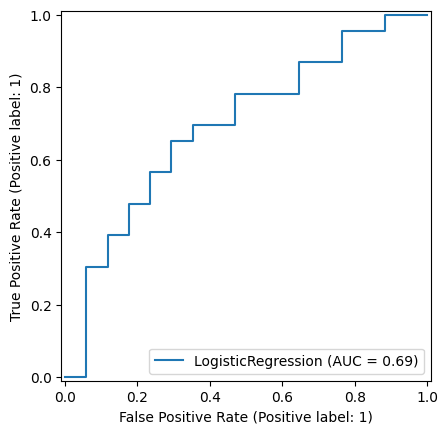

In [17]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

## Most Influential Features

This visualization highlights the features that have the greatest influence on the loan repayment prediction. Features with larger absolute coefficient values have a stronger impact on the model's decision.

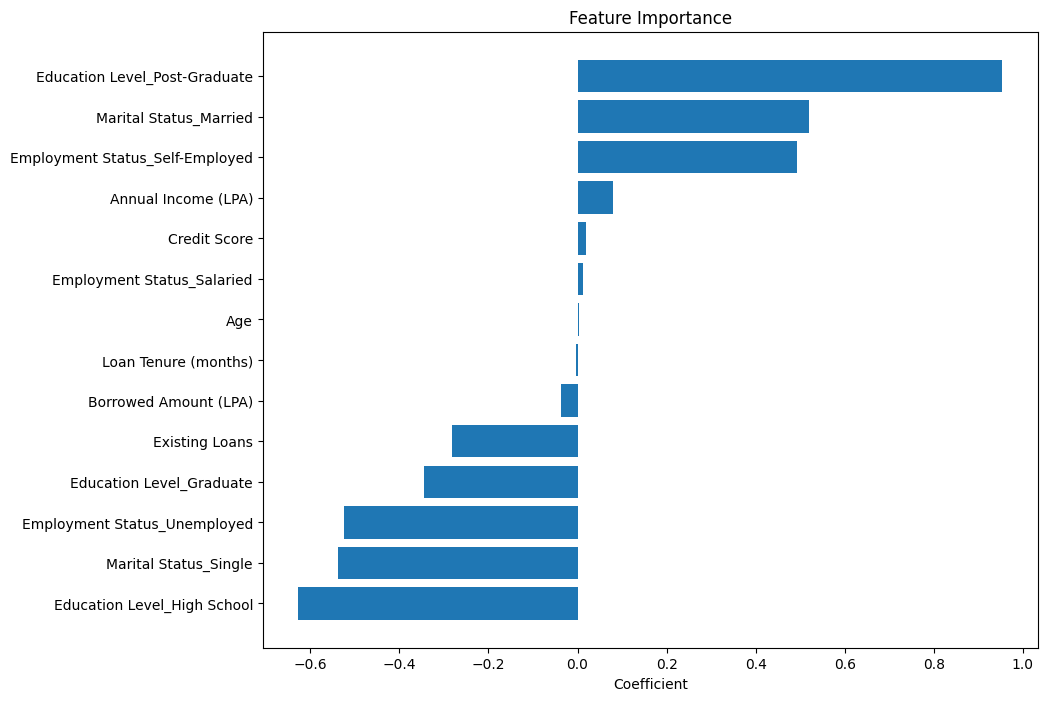

In [18]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef = coef.sort_values("Coefficient")

plt.figure(figsize=(10,8))
plt.barh(coef["Feature"], coef["Coefficient"])
plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.show()

## Confusion Matrix

The confusion matrix provides a detailed summary of the Logistic Regression model's predictions. It compares the actual loan repayment status with the predicted status and helps identify correct predictions as well as classification errors.

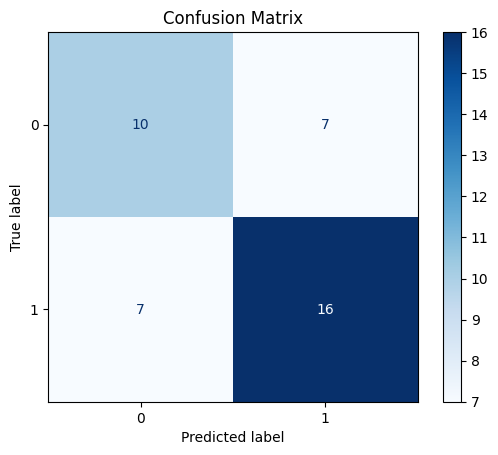

In [19]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

### Interpretation

The confusion matrix shows that the model correctly classified **26 out of 40** observations.

- True Negatives (TN): **10**
- False Positives (FP): **7**
- False Negatives (FN): **7**
- True Positives (TP): **16**

The model performs better at identifying **customers who repay the loan (Class 1)** than **customers who do not repay (Class 0)**. However, there are still several misclassifications, indicating that additional feature engineering or more advanced models could improve performance.

# Conclusion

This project demonstrates a complete binary classification workflow using Logistic Regression. The model achieved approximately 65% accuracy on the test dataset. While the performance is moderate, the project successfully illustrates data preprocessing, categorical encoding, model training, evaluation, and prediction on unseen data. Future improvements could include feature engineering, hyperparameter tuning, and testing more advanced classification algorithms such as Random Forest and XGBoost.
